# Inventory Policy Optimization Engine

This notebook compares different inventory decision policies derived from the forecasting and uncertainty pipeline.

The goal is to move from prediction to decision-making. Earlier notebooks generated LightGBM point forecasts, conformal prediction intervals, safety stock signals, and lead-time scenario results. This notebook compares multiple policy rules and identifies which policy gives the best cost-service tradeoff.

Policies compared:
- Point Forecast Policy
- Tuned Conformal Safety Stock Policy
- Lead-Time Scenario Policy
- Newsvendor-style Critical Ratio Policy

In [1]:
#Setup and load conformal prediction data
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

df = pd.read_csv("data/processed/conformal_predictions_phase3.csv")

print("Data shape:", df.shape)
print(df.columns.tolist())

df[['id', 'sales', 'prediction', 'lower_bound', 'upper_bound']].head()

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or
Data shape: (2940, 34)
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'avg_demand', 'std_demand', 'cv', 'zero_demand_ratio', 'sales', 'day', 'd', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'day_of_week', 'is_weekend', 'month_num', 'quarter', 'year_num', 'lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'prediction', 'lower_bound', 'upper_bound']


,id,sales,prediction,lower_bound,upper_bound
0,FOODS_1_022_CA_4_validation,0,0.087015,0.0,1.810284
1,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
2,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
3,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
4,FOODS_1_022_CA_4_validation,0,0.103592,0.0,1.826860


## Data Loading Observation

The conformal prediction output from Notebook 05 is used as the input for this policy optimization notebook. This keeps the pipeline connected: LightGBM forecasts and conformal uncertainty intervals are now being converted into inventory policy decisions.

In [2]:
df['prediction'] = df['prediction'].clip(lower=0)
df['lower_bound'] = df['lower_bound'].clip(lower=0)
df['upper_bound'] = df['upper_bound'].clip(lower=0)

df['safety_stock_signal'] = df['upper_bound'] - df['prediction']
df['safety_stock_signal'] = df['safety_stock_signal'].clip(lower=0)

df[['sales', 'prediction', 'lower_bound', 'upper_bound', 'safety_stock_signal']].head()

,sales,prediction,lower_bound,upper_bound,safety_stock_signal
0,0,0.087015,0.0,1.810284,1.723269
1,0,0.083071,0.0,1.806339,1.723269
2,0,0.083071,0.0,1.806339,1.723269
3,0,0.083071,0.0,1.806339,1.723269
4,0,0.103592,0.0,1.826860,1.723269


## Uncertainty Signal Observation

The safety stock signal is calculated as the gap between the conformal upper bound and the point forecast. This gap represents demand uncertainty. A larger gap means the model is less certain and therefore suggests a larger potential inventory buffer.

In [3]:
#Define business assumptions and scenarios
holding_cost = 1
stockout_cost = 5

lead_time_scenarios = pd.DataFrame({
    'lead_time_scenario': ['Normal Lead Time', 'Moderate Delay', 'Severe Delay'],
    'lead_time_days': [7, 10, 14],
    'lead_time_probability': [0.60, 0.30, 0.10]
})

demand_scenarios = [
    {
        'demand_scenario': 'Low Demand',
        'column': 'lower_bound',
        'probability': 0.20
    },
    {
        'demand_scenario': 'Expected Demand',
        'column': 'prediction',
        'probability': 0.50
    },
    {
        'demand_scenario': 'High Demand',
        'column': 'upper_bound',
        'probability': 0.30
    }
]

print("Holding cost:", holding_cost)
print("Stockout cost:", stockout_cost)

print("\nLead-time scenarios:")
print(lead_time_scenarios)

print("\nDemand scenarios:")
for scenario in demand_scenarios:
    print(scenario)

Holding cost: 1
Stockout cost: 5

Lead-time scenarios:
  lead_time_scenario  lead_time_days  lead_time_probability
0   Normal Lead Time               7                    0.6
1     Moderate Delay              10                    0.3
2       Severe Delay              14                    0.1

Demand scenarios:
{'demand_scenario': 'Low Demand', 'column': 'lower_bound', 'probability': 0.2}
{'demand_scenario': 'Expected Demand', 'column': 'prediction', 'probability': 0.5}
{'demand_scenario': 'High Demand', 'column': 'upper_bound', 'probability': 0.3}


## Scenario Setup Observation

The policy engine evaluates inventory decisions under both demand uncertainty and lead-time uncertainty. Demand uncertainty comes from the conformal prediction interval, while lead-time uncertainty is represented through normal, moderately delayed, and severely delayed replenishment scenarios.

This keeps the implementation simple while still aligning with the research goal of moving beyond fixed lead-time assumptions.

In [7]:
selected_fixed_lead_time_factor = 0.6
selected_lead_time_scenario_factor = 1.0

critical_ratio = stockout_cost / (stockout_cost + holding_cost)

print("Fixed lead-time selected safety factor:", selected_fixed_lead_time_factor)
print("Lead-time scenario selected safety factor:", selected_lead_time_scenario_factor)
print("Newsvendor-style critical ratio:", critical_ratio)


def point_forecast_policy(data, lead_time):
    """
    Uses only the LightGBM point forecast.
    This is the simplest policy and ignores uncertainty.
    """
    return np.ceil(data['prediction'] * lead_time)


def tuned_conformal_policy(data, lead_time):
    """
    Uses the fixed lead-time tuned conformal safety factor from Notebook 06.
    """
    return np.ceil(
        data['prediction'] * lead_time
        + selected_fixed_lead_time_factor * data['safety_stock_signal'] * lead_time
    )


def lead_time_scenario_policy(data, lead_time):
    """
    Uses the stronger safety factor selected after lead-time uncertainty analysis in Notebook 07.
    """
    return np.ceil(
        data['prediction'] * lead_time
        + selected_lead_time_scenario_factor * data['safety_stock_signal'] * lead_time
    )


def newsvendor_style_policy(data, lead_time):
    """
    Uses a simple critical-ratio rule inside the conformal interval.
    This is a newsvendor-style approximation, not a full formal newsvendor solver.
    """
    estimated_quantile_demand = (
        data['lower_bound']
        + critical_ratio * (data['upper_bound'] - data['lower_bound'])
    )

    return np.ceil(estimated_quantile_demand * lead_time)

Fixed lead-time selected safety factor: 0.6
Lead-time scenario selected safety factor: 1.0
Newsvendor-style critical ratio: 0.8333333333333334


## Policy Rule Observation

Four inventory policies are compared in this notebook. The point forecast policy uses only the LightGBM prediction and ignores uncertainty. The tuned conformal policy uses the safety factor selected under fixed lead time. The lead-time scenario policy uses the stronger safety factor selected after introducing replenishment uncertainty. The newsvendor-style policy uses the critical ratio to choose a demand level within the conformal interval.

This allows the project to compare simple forecasting-based decisions against uncertainty-aware inventory policies.


In [9]:
#Common scenario evaluation function
def evaluate_policy_under_scenarios(data, policy_function, policy_name):
    total_expected_holding_cost = 0
    total_expected_stockout_cost = 0
    total_expected_cost = 0
    total_expected_stockout_units = 0
    total_expected_demand = 0
    total_expected_stockout_events = 0
    total_weight = 0

    n_rows = len(data)

    for _, lt_row in lead_time_scenarios.iterrows():
        lead_time = lt_row['lead_time_days']
        lead_time_prob = lt_row['lead_time_probability']

        policy_order = policy_function(data, lead_time)

        for scenario in demand_scenarios:
            demand_col = scenario['column']
            demand_prob = scenario['probability']

            scenario_weight = lead_time_prob * demand_prob

            scenario_demand = data[demand_col] * lead_time

            holding_units = np.maximum(policy_order - scenario_demand, 0)
            stockout_units = np.maximum(scenario_demand - policy_order, 0)

            holding_cost_total = holding_units.sum() * holding_cost
            stockout_cost_total = stockout_units.sum() * stockout_cost
            total_cost = holding_cost_total + stockout_cost_total

            stockout_events = (stockout_units > 0).sum()

            total_expected_holding_cost += scenario_weight * holding_cost_total
            total_expected_stockout_cost += scenario_weight * stockout_cost_total
            total_expected_cost += scenario_weight * total_cost
            total_expected_stockout_units += scenario_weight * stockout_units.sum()
            total_expected_demand += scenario_weight * scenario_demand.sum()
            total_expected_stockout_events += scenario_weight * stockout_events
            total_weight += scenario_weight

    fill_rate = 1 - (total_expected_stockout_units / total_expected_demand)

    cycle_service_level = 1 - (
        total_expected_stockout_events / (n_rows * total_weight)
    )

    return {
        'policy_name': policy_name,
        'expected_total_cost': total_expected_cost,
        'expected_holding_cost': total_expected_holding_cost,
        'expected_stockout_cost': total_expected_stockout_cost,
        'expected_stockout_units': total_expected_stockout_units,
        'expected_demand': total_expected_demand,
        'fill_rate': fill_rate,
        'cycle_service_level': cycle_service_level
    }

In [10]:
#Compare all policies
policy_results = []

policy_results.append(
    evaluate_policy_under_scenarios(
        df,
        point_forecast_policy,
        "Point Forecast Policy"
    )
)

policy_results.append(
    evaluate_policy_under_scenarios(
        df,
        tuned_conformal_policy,
        "Tuned Conformal Policy"
    )
)

policy_results.append(
    evaluate_policy_under_scenarios(
        df,
        lead_time_scenario_policy,
        "Lead-Time Scenario Policy"
    )
)

policy_results.append(
    evaluate_policy_under_scenarios(
        df,
        newsvendor_style_policy,
        "Newsvendor-Style Critical Ratio Policy"
    )
)

policy_results_df = pd.DataFrame(policy_results)

summary_cols = [
    'policy_name',
    'expected_total_cost',
    'expected_holding_cost',
    'expected_stockout_cost',
    'expected_stockout_units',
    'fill_rate',
    'cycle_service_level'
]

policy_results_df[summary_cols]

,policy_name,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,fill_rate,cycle_service_level
0,Point Forecast Policy,67587.623911,4534.008636,63053.615275,12610.723055,0.608118,0.7
1,Tuned Conformal Policy,46738.983911,22776.568636,23962.415275,4792.483055,0.851072,0.7
2,Lead-Time Scenario Policy,35474.685581,35474.685581,0.000000,0.000000,1.000000,1.0
3,Newsvendor-Style Critical Ratio Policy,40892.263911,27892.448636,12999.815275,2599.963055,0.919205,0.7


## Policy Comparison Observation

The policy comparison shows that the point forecast policy performs poorly under demand and lead-time uncertainty. Although it has the lowest holding cost, it produces very high stockout cost and only a 60.81% fill rate. This confirms that point forecasts alone are not sufficient for inventory decision-making under intermittent demand.

The tuned conformal policy improves performance by converting forecast uncertainty into safety stock. It reduces expected stockout units substantially compared to the point forecast policy and increases the fill rate to 85.11%.

The newsvendor-style critical ratio policy performs better than the tuned conformal policy in terms of service level, achieving a fill rate of 91.92%. This shows that cost-aware decision rules can be combined with conformal intervals to generate more practical inventory policies.

The lead-time scenario policy gives the best result under the current assumptions. It achieves the lowest expected total cost, zero expected stockout units, and 100% fill rate. This suggests that when lead-time uncertainty is considered, a stronger safety buffer can reduce stockout penalties enough to become the most cost-effective policy.

In [11]:
target_fill_rate = 0.90

eligible_policies = policy_results_df[
    policy_results_df['fill_rate'] >= target_fill_rate
].copy()

if len(eligible_policies) > 0:
    final_policy = eligible_policies.sort_values(
        by='expected_total_cost'
    ).iloc[0]
    selection_reason = "Lowest expected cost among policies satisfying target fill rate"
else:
    final_policy = policy_results_df.sort_values(
        by='fill_rate',
        ascending=False
    ).iloc[0]
    selection_reason = "Best available service level because no policy met target fill rate"

print("Target Fill Rate:", target_fill_rate)
print("Final Selected Policy:", final_policy['policy_name'])
print("Selection Reason:", selection_reason)
print("Expected Total Cost:", final_policy['expected_total_cost'])
print("Expected Stockout Units:", final_policy['expected_stockout_units'])
print("Fill Rate:", final_policy['fill_rate'])
print("Cycle Service Level:", final_policy['cycle_service_level'])

Target Fill Rate: 0.9
Final Selected Policy: Lead-Time Scenario Policy
Selection Reason: Lowest expected cost among policies satisfying target fill rate
Expected Total Cost: 35474.68558082933
Expected Stockout Units: 0.0
Fill Rate: 1.0
Cycle Service Level: 1.0


## Final Policy Selection Observation

A target fill rate of 90% was used as the business service-level requirement. Among the policies that satisfied this target, the lead-time scenario policy had the lowest expected total cost.

Therefore, the lead-time scenario policy was selected as the final inventory policy in this notebook. This policy accounts for both demand uncertainty and lead-time uncertainty, which makes it more robust than policies based only on point forecasts or fixed lead-time assumptions.

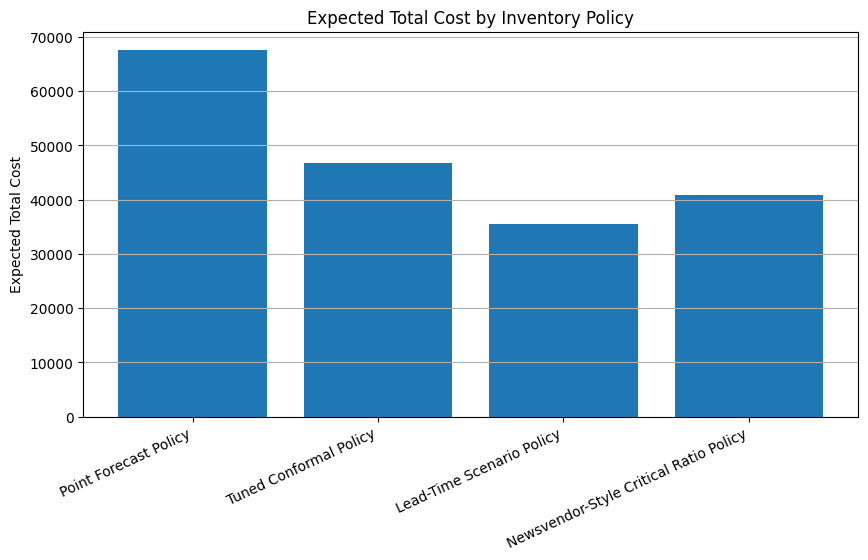

In [12]:
#Graph of expected total cost comparison
plt.figure(figsize=(10, 5))

plt.bar(
    policy_results_df['policy_name'],
    policy_results_df['expected_total_cost']
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Expected Total Cost")
plt.title("Expected Total Cost by Inventory Policy")
plt.grid(axis='y')
plt.show()

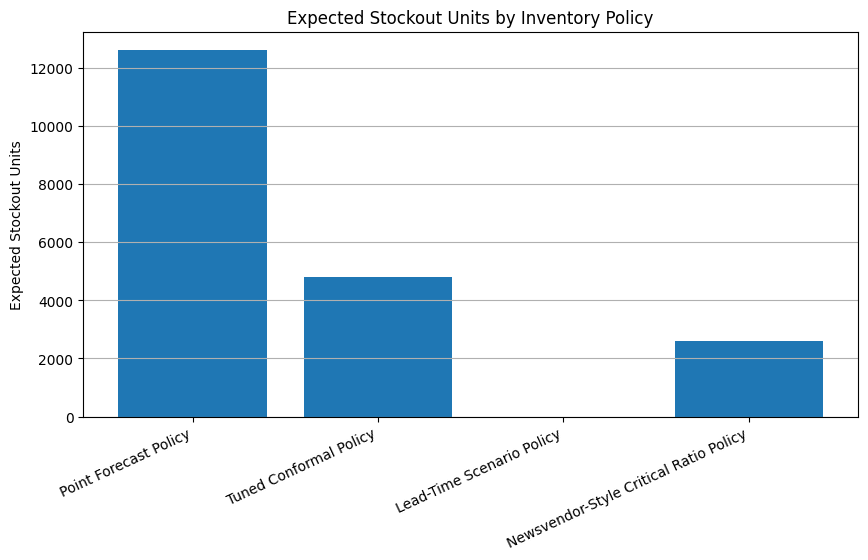

In [13]:
#Graph of stockout units comparison
plt.figure(figsize=(10, 5))

plt.bar(
    policy_results_df['policy_name'],
    policy_results_df['expected_stockout_units']
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Expected Stockout Units")
plt.title("Expected Stockout Units by Inventory Policy")
plt.grid(axis='y')
plt.show()

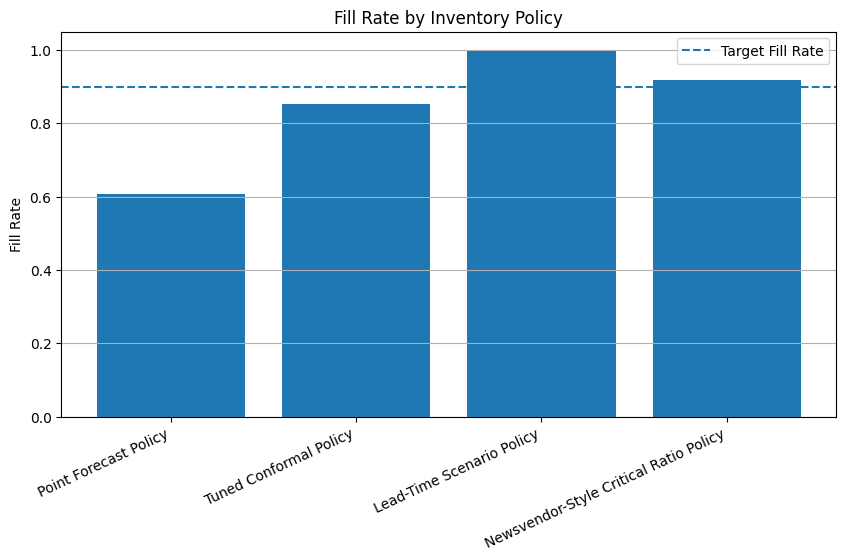

In [14]:
#Graph of fill rate comparison
plt.figure(figsize=(10, 5))

plt.bar(
    policy_results_df['policy_name'],
    policy_results_df['fill_rate']
)

plt.axhline(
    y=target_fill_rate,
    linestyle='--',
    label='Target Fill Rate'
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Fill Rate")
plt.title("Fill Rate by Inventory Policy")
plt.legend()
plt.grid(axis='y')
plt.show()

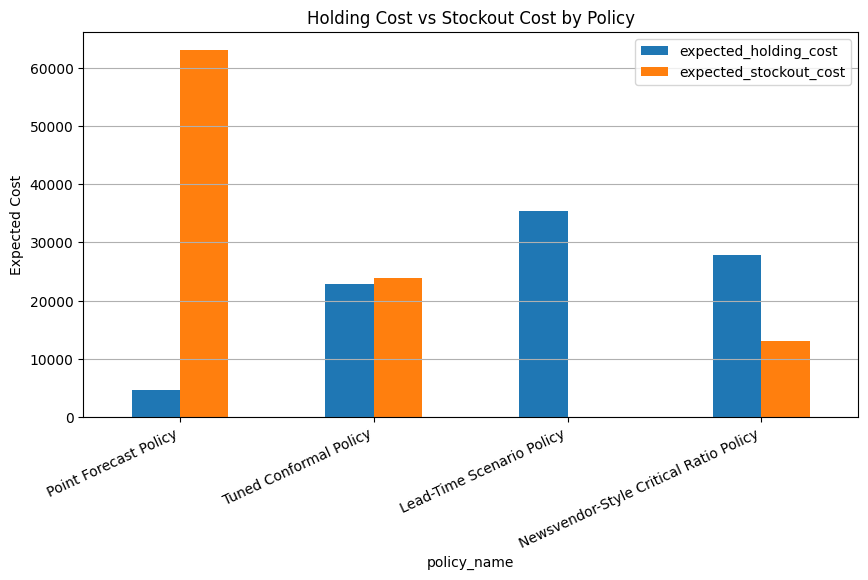

In [15]:
#Graph of holding cost vs stockout cost breakdown
cost_breakdown_df = policy_results_df[
    ['policy_name', 'expected_holding_cost', 'expected_stockout_cost']
].copy()

cost_breakdown_df.set_index('policy_name').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Expected Cost")
plt.title("Holding Cost vs Stockout Cost by Policy")
plt.grid(axis='y')
plt.show()

In [16]:
print("Final Selected Policy:", final_policy['policy_name'])
print("Selection Reason:", selection_reason)
print("Expected Total Cost:", final_policy['expected_total_cost'])
print("Expected Stockout Units:", final_policy['expected_stockout_units'])
print("Fill Rate:", final_policy['fill_rate'])
print("Cycle Service Level:", final_policy['cycle_service_level'])

print("\nPolicy comparison summary:")
print(policy_results_df[
    [
        'policy_name',
        'expected_total_cost',
        'expected_stockout_units',
        'fill_rate',
        'cycle_service_level'
    ]
].to_string(index=False))

Final Selected Policy: Lead-Time Scenario Policy
Selection Reason: Lowest expected cost among policies satisfying target fill rate
Expected Total Cost: 35474.68558082933
Expected Stockout Units: 0.0
Fill Rate: 1.0
Cycle Service Level: 1.0

Policy comparison summary:
                           policy_name  expected_total_cost  expected_stockout_units  fill_rate  cycle_service_level
                 Point Forecast Policy         67587.623911             12610.723055   0.608118                  0.7
                Tuned Conformal Policy         46738.983911              4792.483055   0.851072                  0.7
             Lead-Time Scenario Policy         35474.685581                 0.000000   1.000000                  1.0
Newsvendor-Style Critical Ratio Policy         40892.263911              2599.963055   0.919205                  0.7


## Final Conclusion

This notebook compared four inventory decision policies under a common demand and lead-time scenario framework.

The point forecast policy performed poorly because it ignored uncertainty, resulting in high stockout units and a low fill rate of 60.81%. The tuned conformal policy improved performance by using conformal uncertainty as a safety stock signal. The newsvendor-style critical ratio policy further improved service performance by incorporating cost sensitivity into the decision rule.

The lead-time scenario policy was selected as the final policy because it achieved the lowest expected total cost among all policies satisfying the 90% target fill rate. It produced zero expected stockout units, 100% fill rate, and 100% cycle service level under the tested scenario framework.

This result supports the main research argument: inventory decisions should not rely only on point forecasts. Combining conformal demand uncertainty with lead-time scenario analysis gives a more robust and business-interpretable inventory policy.


In [17]:
policy_results_df.to_csv(
    "data/processed/policy_optimization_results.csv",
    index=False
)

pd.DataFrame([final_policy]).to_csv(
    "data/processed/final_selected_policy.csv",
    index=False
)

print("Saved policy optimization results and final selected policy.")

Saved policy optimization results and final selected policy.


In [18]:
!git status

Refresh index: 100% (10/10), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/07_lead_time_scenario_policy_engine.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/08_inventory_policy_optimization_engine.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
